**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Exploración y Curación de Datos**

*Edición 2025*

----

# Trabajo práctico entregable - parte 1

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [4]:
import matplotlib.pyplot as plt
import numpy
import pandas

import seaborn
seaborn.set_context('talk')

from sqlalchemy import create_engine, text

In [5]:
import plotly
plotly.__version__


'5.24.1'

In [6]:
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
print(melb_df.columns)
# melb_df[:3]

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')


## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar: df.to_sql() infiere tipos automáticamente, pero a veces los nombres de columnas como Date, Price o ID dan problemas si vienen con strings o valores nulos.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por ciudad.
    - cantidad de registros totales por barrio y ciudad.
    - Consulta con filtro: ¿Cuántas propiedades hay por ciudad con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (Type) y ciudad?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL  para obtener un resultado similar a lo realizado con Pandas en clase.  



### 1. Crear una base de datos en SQLite utilizando la librería SQLalchemy

In [7]:
# Crear conexión a una base de datos SQLite en memoria
engine = create_engine('sqlite:///inmobiliaria.db')

### 2. Ingestar los datos en las tablas

In [8]:
from google.colab import drive
drive.mount('/content/drive')

# El dataset generado en clase con datos de airbnb y sus precios por codigo postal lo descargamos ahora
airbnb_df = pandas.read_csv('/content/drive/MyDrive/Colab Notebooks/diplodatos2025/Análisis Exploratorio y Curación de Datos/airbnb_price_by_zipcode.csv')

# Mostrar las primeras filas del dataset de Airbnb
airbnb_df[:3]

Mounted at /content/drive


,zipcode,airbnb_price_mean,airbnb_record_count,airbnb_weekly_price_mean,airbnb_monthly_price_mean
0,2010.0,40.0,1,NaN,NaN
1,2134.0,50.0,1,NaN,NaN
2,2582.0,104.0,1,NaN,NaN


### 3. Validar tipos de columnas antes de guardar

In [9]:
# Función para mostrar los tipos de datos en un dataframe
def mostrar_tipos(df):
    return pandas.DataFrame({'Tipo de dato': df.dtypes, 'Valores nulos': df.isnull().sum()})

# Mostrar los tipos de datos de ambos dataframes
print("Tipos de datos en Melbourne dataset:")
print(mostrar_tipos(melb_df))

print("\nTipos de datos en Airbnb dataset:")
print(mostrar_tipos(airbnb_df))

# Convertir columnas de fechas a datetime si es necesario
if 'Date' in melb_df.columns:
    melb_df['Date'] = pandas.to_datetime(melb_df['Date'], errors='coerce')

# Asegurar que las columnas de precios sean numéricas
for df in [melb_df, airbnb_df]:
    price_cols = [col for col in df.columns if 'price' in col.lower() or 'Price' in col]
    for col in price_cols:
        df[col] = pandas.to_numeric(df[col], errors='coerce')

# Guardar los dataframes en la base de datos
melb_df.to_sql('melbourne_properties', engine, if_exists='replace', index=False)
airbnb_df.to_sql('airbnb_listings', engine, if_exists='replace', index=False)

Tipos de datos en Melbourne dataset:
              Tipo de dato  Valores nulos
Suburb              object              0
Address             object              0
Rooms                int64              0
Type                object              0
Price              float64              0
Method              object              0
SellerG             object              0
Date                object              0
Distance           float64              0
Postcode           float64              0
Bedroom2           float64              0
Bathroom           float64              0
Car                float64             62
Landsize           float64              0
BuildingArea       float64           6450
YearBuilt          float64           5375
CouncilArea         object           1369
Lattitude          float64              0
Longtitude         float64              0
Regionname          object              0
Propertycount      float64              0

Tipos de datos en Airbnb dataset:
    

247

### 4. Implementar consultas en SQL

#### Función para ejecutar consultas y mostrar resultados

In [10]:
def ejecutar_consulta(query):
    with engine.connect() as conn:
        result = conn.execute(text(query))
        return pandas.DataFrame(result.fetchall(), columns=result.keys())

#### Cantidad de registros totales por ciudad

In [16]:
query1 = """
SELECT Regionname as Region, COUNT(*) as Total_Registros
FROM melbourne_properties
GROUP BY Regionname
ORDER BY Total_Registros DESC
"""
resultados_por_ciudad = ejecutar_consulta(query1)
print("Registros totales por ciudad/region:")
resultados_por_ciudad.head(10)

Registros totales por ciudad/region:


,Region,Total_Registros
0,Southern Metropolitan,4695
1,Northern Metropolitan,3890
2,Western Metropolitan,2948
3,Eastern Metropolitan,1471
4,South-Eastern Metropolitan,450
5,Eastern Victoria,53
6,Northern Victoria,41
7,Western Victoria,32


#### Cantidad de registros totales por barrio y ciudad

In [17]:
query2 = """
SELECT Suburb as Barrio, Regionname as Region, COUNT(*) as Total_Registros
FROM melbourne_properties
GROUP BY Suburb, Regionname
ORDER BY Total_Registros DESC
"""
resultados_por_barrio_ciudad = ejecutar_consulta(query2)
print("Registros totales por barrio y ciudad:")
resultados_por_barrio_ciudad.head(10)

Registros totales por barrio y ciudad:


,Barrio,Region,Total_Registros
0,Reservoir,Northern Metropolitan,359
1,Richmond,Northern Metropolitan,260
2,Bentleigh East,Southern Metropolitan,249
3,Preston,Northern Metropolitan,239
4,Brunswick,Northern Metropolitan,222
5,Essendon,Western Metropolitan,220
6,South Yarra,Southern Metropolitan,202
7,Glen Iris,Southern Metropolitan,195
8,Hawthorn,Southern Metropolitan,191
9,Coburg,Northern Metropolitan,190


#### Propiedades por ciudad con más de 2 habitaciones

In [18]:
query3 = """
SELECT Regionname as Region, COUNT(*) as Total_Propiedades
FROM melbourne_properties
WHERE Rooms > 2
GROUP BY Regionname
ORDER BY Total_Propiedades DESC
"""
propiedades_mas_de_2_habitaciones = ejecutar_consulta(query3)
print("Propiedades por ciudad con más de 2 habitaciones:")
propiedades_mas_de_2_habitaciones.head(10)

Propiedades por ciudad con más de 2 habitaciones:


,Region,Total_Propiedades
0,Southern Metropolitan,2848
1,Northern Metropolitan,2389
2,Western Metropolitan,2259
3,Eastern Metropolitan,1228
4,South-Eastern Metropolitan,407
5,Eastern Victoria,50
6,Northern Victoria,39
7,Western Victoria,31


#### Precio promedio de propiedades según tipo y ciudad

In [19]:
query4 = """
SELECT Type as Tipo, Regionname as Region,
       ROUND(AVG(Price), 2) as Precio_AUD
FROM melbourne_properties
GROUP BY Type, Regionname
ORDER BY Precio_AUD DESC
"""

# Definir la tasa de cambio (ejemplo: 1 AUD = 0.64 USD)
tasa_aud_a_usd = 0.64

precio_promedio_por_tipo_ciudad = ejecutar_consulta(query4)

# Convertir de AUD a USD y formatear
precio_promedio_por_tipo_ciudad['Precio_USD'] = precio_promedio_por_tipo_ciudad['Precio_AUD'].apply(
    lambda x: f"${x * tasa_aud_a_usd:,.2f}" if pandas.notnull(x) else "N/A")

precio_promedio_por_tipo_ciudad['Precio_AUD'] = precio_promedio_por_tipo_ciudad['Precio_AUD'].apply(
    lambda x: f"A${x:,.2f}" if pandas.notnull(x) else "N/A")

print("Precio promedio por tipo y ciudad:")
precio_promedio_por_tipo_ciudad.head(10)

Precio promedio por tipo y ciudad:


,Tipo,Region,Precio_AUD,Precio_USD
0,h,Southern Metropolitan,"A$1,802,241.08","$1,153,434.29"
1,t,Southern Metropolitan,"A$1,205,404.47","$771,458.86"
2,h,Eastern Metropolitan,"A$1,197,450.46","$766,368.29"
3,h,Northern Metropolitan,"A$1,021,221.87","$653,582.00"
4,h,South-Eastern Metropolitan,"A$955,949.62","$611,807.76"
5,h,Western Metropolitan,"A$950,766.27","$608,490.41"
6,t,South-Eastern Metropolitan,"A$913,270.00","$584,492.80"
7,t,Eastern Metropolitan,"A$869,619.92","$556,556.75"
8,t,Northern Metropolitan,"A$749,608.31","$479,749.32"
9,t,Western Metropolitan,"A$720,951.05","$461,408.67"


#### Top 5 barrios con propiedades más caras en promedio

In [20]:
query5 = """
SELECT Suburb as Barrio,
       AVG(Price) as Precio_AUD
FROM melbourne_properties
GROUP BY Suburb
ORDER BY Precio_AUD DESC
LIMIT 5
"""
top_5_barrios_caros = ejecutar_consulta(query5)

# Definir la tasa de cambio (ejemplo: 1 AUD = 0.64 USD)
tasa_aud_a_usd = 0.64

# Convertir de AUD a USD y formatear
top_5_barrios_caros['Precio_USD'] = top_5_barrios_caros['Precio_AUD'].apply(
    lambda x: f"${x * tasa_aud_a_usd:,.2f}" if pandas.notnull(x) else "N/A")

# Formatear la columna AUD también para mostrar ambas monedas
top_5_barrios_caros['Precio_AUD'] = top_5_barrios_caros['Precio_AUD'].apply(
    lambda x: f"A${x:,.2f}" if pandas.notnull(x) else "N/A")

print("Top 5 barrios con propiedades más caras:")
top_5_barrios_caros

Top 5 barrios con propiedades más caras:


,Barrio,Precio_AUD,Precio_USD
0,Kooyong,"A$2,185,000.00","$1,398,400.00"
1,Canterbury,"A$2,180,240.74","$1,395,354.07"
2,Middle Park,"A$2,082,529.41","$1,332,818.82"
3,Albert Park,"A$1,941,355.07","$1,242,467.25"
4,Brighton,"A$1,930,158.00","$1,235,301.12"


### 5. Combinar los datasets con JOIN

In [21]:
# JOIN entre las tablas y agrupación por código postal para análisis
query_join = """
SELECT m.Suburb, m.Postcode, m.Type,
       m.Price as Melbourne_Price,
       a.airbnb_price_mean as Airbnb_Price_Daily,
       a.airbnb_weekly_price_mean as Airbnb_Price_Weekly,
       a.airbnb_monthly_price_mean as Airbnb_Price_Monthly,
       a.airbnb_record_count as Airbnb_Listings_Count
FROM melbourne_properties m
JOIN airbnb_listings a ON m.Postcode = a.zipcode
"""

resultados_join_raw = ejecutar_consulta(query_join)

# Agrupar por código postal para un análisis más significativo
analisis_por_cp = resultados_join_raw.groupby(['Suburb', 'Postcode']).agg({
    'Melbourne_Price': ['mean', 'min', 'max', 'count'],
    'Airbnb_Price_Monthly': 'first',  # Son iguales por CP, tomamos el primero
    'Airbnb_Listings_Count': 'first'   # Son iguales por CP, tomamos el primero
}).reset_index()

# Renombrar columnas para mayor claridad
analisis_por_cp.columns = [
    'Suburb', 'Postcode',
    'Precio_Prop_Promedio', 'Precio_Prop_Min', 'Precio_Prop_Max', 'Cantidad_Propiedades',
    'Precio_Airbnb_Mensual', 'Cantidad_Listings_Airbnb'
]

analisis_por_cp[:3]

,Suburb,Postcode,Precio_Prop_Promedio,Precio_Prop_Min,Precio_Prop_Max,Cantidad_Propiedades,Precio_Airbnb_Mensual,Cantidad_Listings_Airbnb
0,Abbotsford,3067.0,1.060366e+06,300000.0,1876000.0,56,2187.032258,258
1,Aberfeldie,3040.0,1.277455e+06,280000.0,3900000.0,44,3366.666667,56
2,Airport West,3042.0,7.566567e+05,440000.0,1250000.0,67,1800.750000,35


#### Análisis post join datasets

In [22]:
# Calcular ratio precio/alquiler anual (ROI bruto potencial)
analisis_por_cp['ROI_Potencial_Anual'] = (analisis_por_cp['Precio_Airbnb_Mensual'] * 12) / analisis_por_cp['Precio_Prop_Promedio'] * 100

# Calcular años para recuperar inversión (precio/alquiler anual)
analisis_por_cp['Años_Recuperacion'] = analisis_por_cp['Precio_Prop_Promedio'] / (analisis_por_cp['Precio_Airbnb_Mensual'] * 12)

# Ordenar por ROI potencial para ver las áreas más rentables
analisis_ordenado = analisis_por_cp.sort_values('ROI_Potencial_Anual', ascending=False)

# Aplicar formato de dólares a las columnas de precios
columnas_precio = ['Precio_Prop_Promedio', 'Precio_Prop_Min', 'Precio_Prop_Max', 'Precio_Airbnb_Mensual']
for col in columnas_precio:
    analisis_ordenado[col + '_Formato'] = analisis_ordenado[col].apply(lambda x: f"${x:,.2f}")

# Aplicar formato porcentual al ROI
analisis_ordenado['ROI_Potencial_Anual_Formato'] = analisis_ordenado['ROI_Potencial_Anual'].apply(lambda x: f"{x:.2f}%")

print("Análisis por código postal (Top 15 áreas con mejor ROI potencial):")

# Seleccionar columnas para mostrar
columnas_mostrar = ['Suburb', 'Postcode', 'Precio_Prop_Promedio_Formato',
                    'Precio_Airbnb_Mensual_Formato', 'Cantidad_Propiedades',
                    'Cantidad_Listings_Airbnb', 'ROI_Potencial_Anual_Formato', 'Años_Recuperacion']
analisis_ordenado[columnas_mostrar].head(15)

Análisis por código postal (Top 15 áreas con mejor ROI potencial):


,Suburb,Postcode,Precio_Prop_Promedio_Formato,Precio_Airbnb_Mensual_Formato,Cantidad_Propiedades,Cantidad_Listings_Airbnb,ROI_Potencial_Anual_Formato,Años_Recuperacion
301,Wonga Park,3115.0,"$900,000.00","$10,060.00",1,7,13.41%,7.455268
24,Beaconsfield Upper,3808.0,"$675,000.00","$7,500.00",1,4,13.33%,7.500000
96,Diggers Rest,3427.0,"$525,000.00","$5,250.00",2,7,12.00%,8.333333
168,Kilsyth,3137.0,"$776,000.00","$7,000.00",4,9,10.82%,9.238095
220,Pakenham,3810.0,"$496,333.33","$3,800.00",3,22,9.19%,10.884503
89,Dandenong,3175.0,"$610,961.54","$4,359.00",13,42,8.56%,11.680078
253,Southbank,3006.0,"$634,012.20","$4,358.56",41,1268,8.25%,12.121983
90,Dandenong North,3175.0,"$648,593.75","$4,359.00",16,42,8.06%,12.399513
142,Hawthorn,3122.0,"$1,276,790.58","$8,158.90",191,184,7.67%,13.040877
144,Healesville,3777.0,"$650,000.00","$3,802.19",1,187,7.02%,14.246185


#### Conclusiones
- El uso de SQL permite analizar nuestros datasets de forma muy eficiente y versátil a través de queries
- En proceso de join entre datasets resultó más intuitivo que el realizado con Pandas

---
---
## Ejercicio 2 - Pandas:

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2.  Mostrar la dispersión o distribución de las columnas seleccionadas.
 3.  Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás



2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (porque no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?



---

## Ejercicio 2.1

In [ ]:
import matplotlib.pyplot as plt
import numpy
import pandas as pd

import seaborn as sns
sns.set_context('talk')

from sqlalchemy import create_engine, text

interesting_cols = ['Price', 'Type', 'YearBuilt', 'Postcode', 'Suburb', 'Rooms']
melb_df_i_columns = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv',
    usecols=interesting_cols)
melb_df_i_columns[:3]

# melb_df_i_columns.to_csv('melb_df_i_columns.csv', index=False)

,Suburb,Rooms,Type,Price,Postcode,YearBuilt
0,Abbotsford,2,h,1480000.0,3067.0,NaN
1,Abbotsford,2,h,1035000.0,3067.0,1900.0
2,Abbotsford,3,h,1465000.0,3067.0,1900.0


Las columnas seleccionadas y su justificación:

1. Price: Variable objetivo que queremos predecir, representa el valor de la propiedad.
2. Type: Tipo de propiedad (casa, unidad, etc.), importante determinante del precio.
3. YearBuilt: Año de construcción, indica la antigüedad de la propiedad que influye en el precio.
4. Postcode: Código postal, proxy de la ubicación que es uno de los factores más importantes en el valor.
5. Suburb: Barrio, indica la zona específica que tiene gran impacto en los precios inmobiliarios.
6. Rooms: Número de habitaciones, característica física básica que determina el tamaño y precio.

Columnas no seleccionadas y justificación:
- Address: Demasiado específica y no generalizable para predicción.
- Method y SellerG: Relacionadas con el proceso de venta, no con características intrínsecas.
- Date: El momento de venta puede influir pero buscamos factores permanentes de la propiedad.
- Distance: Puede ser útil pero Suburb y Postcode ya capturan la información de ubicación.
- Bedroom2, Bathroom, Car: Correlacionadas con Rooms o menos importantes para una primera aproximación.
- Landsize, BuildingArea: Importantes, pero con muchos valores faltantes que complicarían el análisis inicial.
- CouncilArea: Información redundante con Suburb y Postcode.
- Lattitude/Longtitude: La ubicación ya está representada por Suburb y Postcode.
- Propertycount: Dato agregado que puede introducir ruido en el análisis a nivel de propiedad individual.

### 1.1 Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?


In [ ]:
missing_values = melb_df_i_columns.isnull().any(axis=1).sum()
total_rows = len(melb_df_i_columns)
missing_percentage = (missing_values / total_rows) * 100

print(f"\n1.1 ANÁLISIS DE VALORES FALTANTES:")
print(f"Filas con al menos un valor faltante: {missing_values} de {total_rows} ({missing_percentage:.2f}%)")

# Detallar los valores faltantes por columna
missing_by_column = melb_df_i_columns.isnull().sum()
missing_percentage_by_column = (missing_by_column / total_rows) * 100
missing_data = pd.DataFrame({
    'Valores faltantes': missing_by_column,
    'Porcentaje': missing_percentage_by_column
})
print("\nValores faltantes por columna:")
print(missing_data[missing_data['Valores faltantes'] > 0])



1.1 ANÁLISIS DE VALORES FALTANTES:
Filas con al menos un valor faltante: 5375 de 13580 (39.58%)

Valores faltantes por columna:
           Valores faltantes  Porcentaje
YearBuilt               5375   39.580265


### 1.2. Mostrar la dispersión o distribución de las columnas seleccionadas.



2. DISTRIBUCIÓN DE LAS COLUMNAS SELECCIONADAS:

Estadísticas descriptivas:
             count          mean            std      min       25%       50%  \
Rooms      13580.0  2.937997e+00       0.955748      1.0       2.0       3.0   
Price      13580.0  1.075684e+06  639310.724296  85000.0  650000.0  903000.0   
Postcode   13580.0  3.105302e+03      90.676964   3000.0    3044.0    3084.0   
YearBuilt   8205.0  1.964684e+03      37.273762   1196.0    1940.0    1970.0   

                 75%        max  
Rooms            3.0       10.0  
Price      1330000.0  9000000.0  
Postcode      3148.0     3977.0  
YearBuilt     1999.0     2018.0  

Distribución de Types (tipos de propiedades):
Type
h    9449
u    3017
t    1114
Name: count, dtype: int64

Porcentaje por tipo:
Type
h    69.580265
u    22.216495
t     8.203240
Name: count, dtype: float64

Top 10 Suburbs por cantidad de propiedades:
Suburb
Reservoir         359
Richmond          260
Bentleigh East    249
Preston           239
Bruns

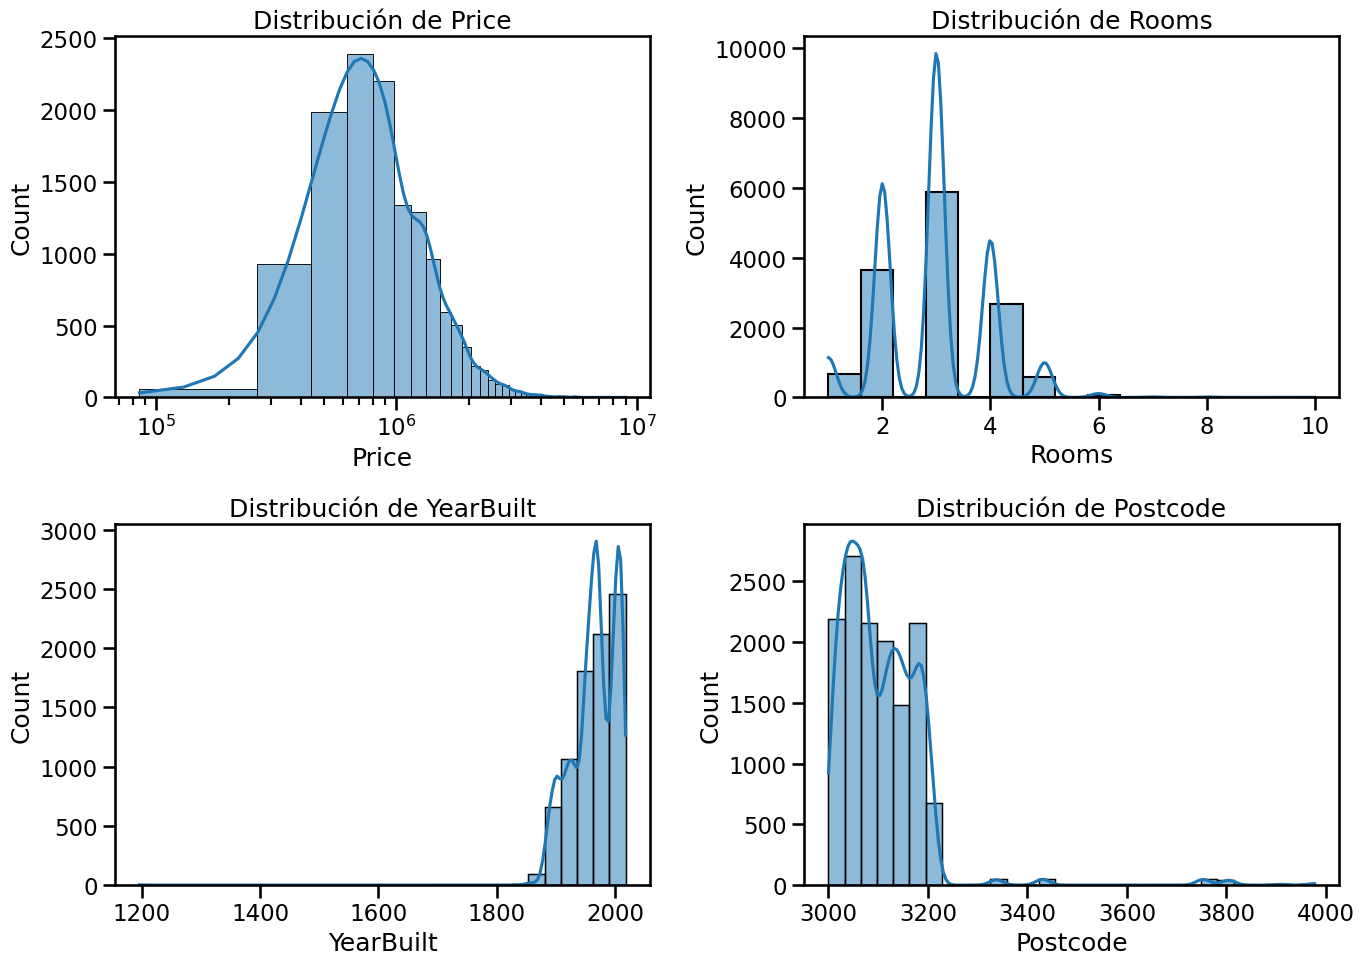

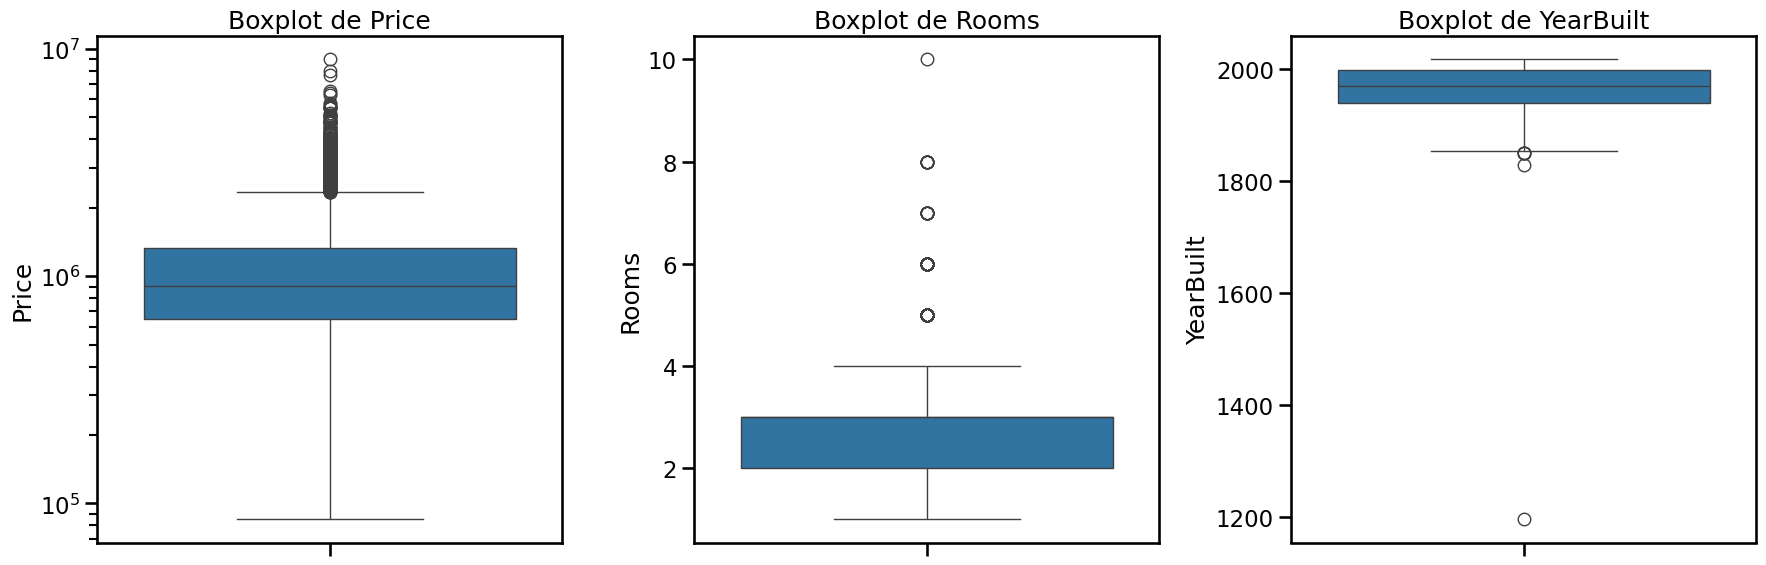

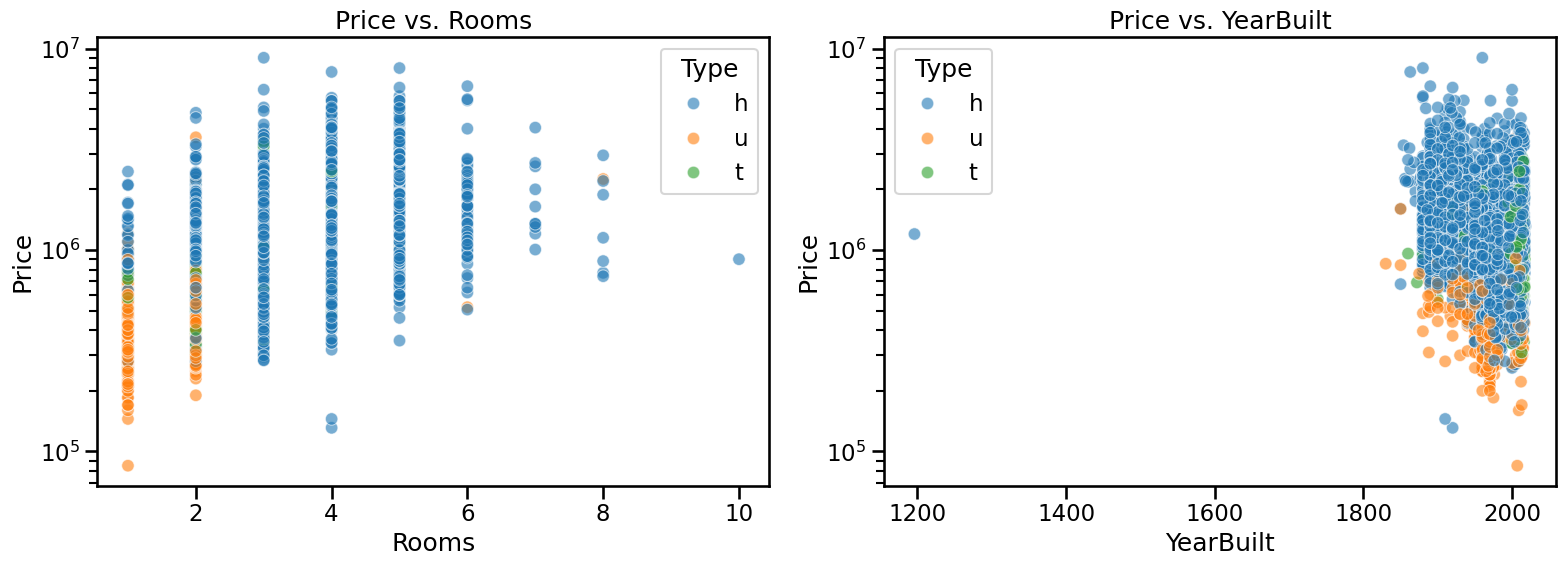

In [ ]:
print("\n2. DISTRIBUCIÓN DE LAS COLUMNAS SELECCIONADAS:")

# Estadísticas descriptivas para todas las columnas
print("\nEstadísticas descriptivas:")
print(melb_df_i_columns.describe().T)

# Distribución de columnas categóricas
print("\nDistribución de Types (tipos de propiedades):")
type_counts = melb_df_i_columns['Type'].value_counts()
print(type_counts)
print("\nPorcentaje por tipo:")
print(type_counts / len(melb_df_i_columns) * 100)

# Top 10 Suburbs por cantidad de propiedades
print("\nTop 10 Suburbs por cantidad de propiedades:")
suburb_counts = melb_df_i_columns['Suburb'].value_counts().head(10)
print(suburb_counts)

# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de Price
sns.histplot(melb_df_i_columns['Price'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Price')
axes[0, 0].set_xscale('log')  # Escala logarítmica para mejor visualización

# Histograma de Rooms
sns.histplot(melb_df_i_columns['Rooms'], bins=15, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Rooms')

# Histograma de YearBuilt
sns.histplot(melb_df_i_columns['YearBuilt'].dropna(), bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribución de YearBuilt')

# Histograma de Postcode
sns.histplot(melb_df_i_columns['Postcode'], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Postcode')

plt.tight_layout()
plt.savefig('histogramas_distribuciones.png')

# Boxplots para variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=melb_df_i_columns['Price'], ax=axes[0])
axes[0].set_title('Boxplot de Price')
axes[0].set_yscale('log')  # Escala logarítmica para mejor visualización

sns.boxplot(y=melb_df_i_columns['Rooms'], ax=axes[1])
axes[1].set_title('Boxplot de Rooms')

sns.boxplot(y=melb_df_i_columns['YearBuilt'].dropna(), ax=axes[2])
axes[2].set_title('Boxplot de YearBuilt')

plt.tight_layout()
plt.savefig('boxplots_variables.png')

# Gráficos de dispersión entre variables
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Relación entre Price y Rooms
sns.scatterplot(x='Rooms', y='Price', hue='Type', data=melb_df_i_columns, alpha=0.6, ax=axes[0])
axes[0].set_title('Price vs. Rooms')
axes[0].set_yscale('log')  # Escala logarítmica para mejor visualización

# Relación entre Price y YearBuilt
year_price_data = melb_df_i_columns.dropna(subset=['YearBuilt'])
sns.scatterplot(x='YearBuilt', y='Price', hue='Type', data=year_price_data, alpha=0.6, ax=axes[1])
axes[1].set_title('Price vs. YearBuilt')
axes[1].set_yscale('log')  # Escala logarítmica para mejor visualización

plt.tight_layout()
plt.savefig('scatter_plots.png')

### 1.3. Eliminar los valores extremos que no sean relevantes


3. DETECCIÓN Y ELIMINACIÓN DE VALORES EXTREMOS:
Límites para Price: [-370000.00, 2350000.00]
Número de outliers en Price: 612
Límites para Rooms: [0.50, 4.50]
Número de outliers en Rooms: 682
Límites para YearBuilt: [1851.50, 2087.50]
Número de outliers en YearBuilt: 6

Dimensiones originales del dataset: (13580, 6)
Dimensiones del dataset después de eliminar outliers: (13448, 6)
Se eliminaron 132 filas por ser valores extremos


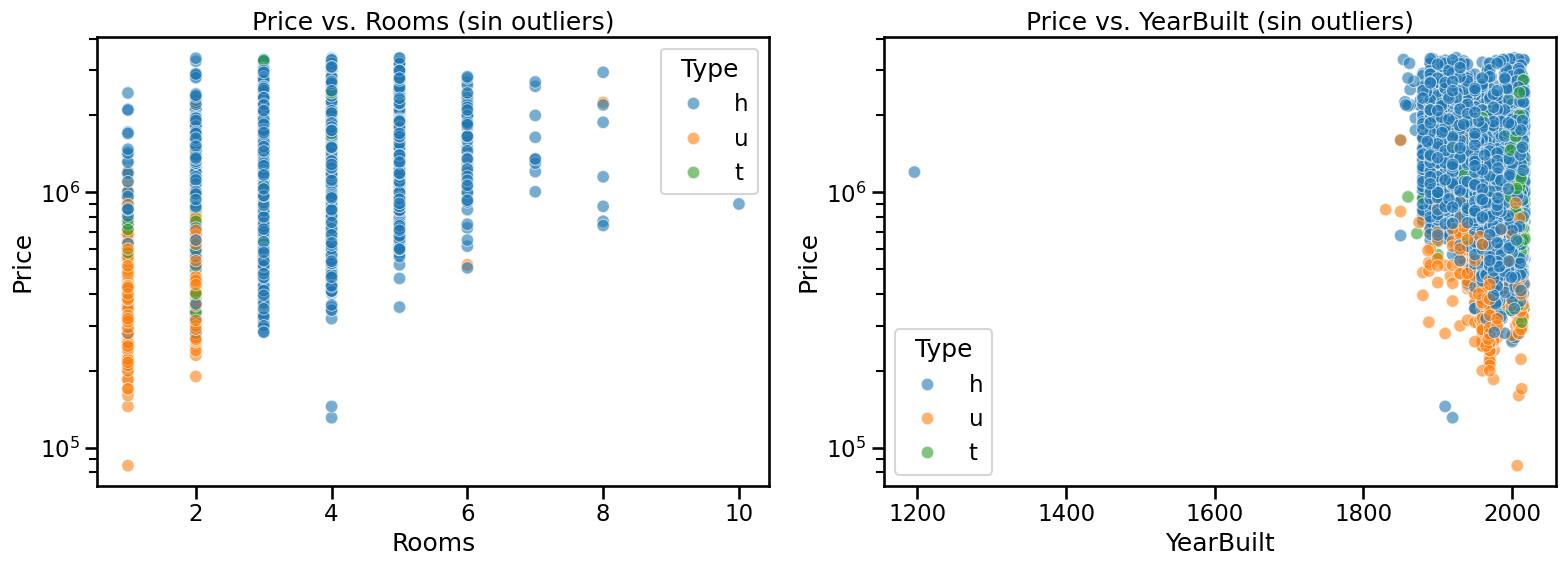

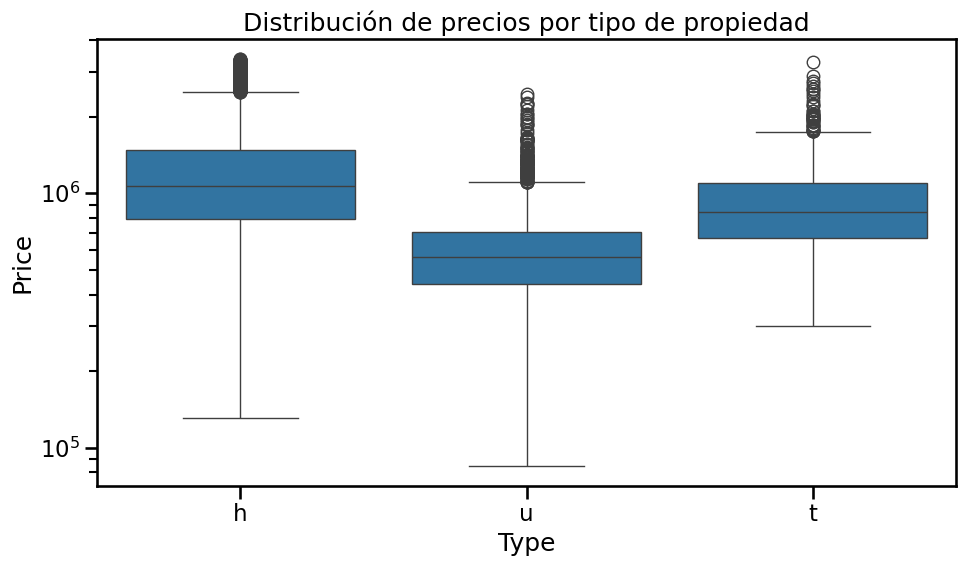

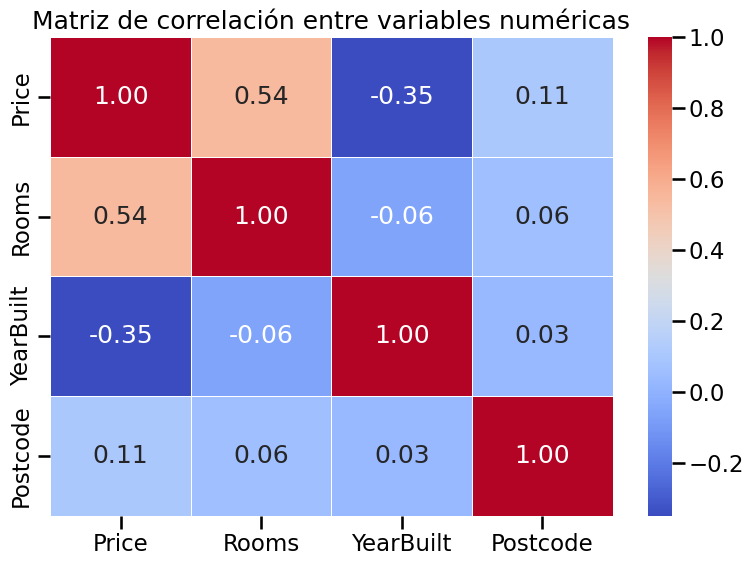

In [ ]:
# Función para detectar outliers usando IQR
def detect_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

# Detectar outliers en Price
lower_bound_price, upper_bound_price = detect_outliers(melb_df_i_columns, 'Price')
print("\n3. DETECCIÓN Y ELIMINACIÓN DE VALORES EXTREMOS:")
print(f"Límites para Price: [{lower_bound_price:.2f}, {upper_bound_price:.2f}]")
outliers_price = melb_df_i_columns[(melb_df_i_columns['Price'] < lower_bound_price) | (melb_df_i_columns['Price'] > upper_bound_price)]
print(f"Número de outliers en Price: {len(outliers_price)}")

# Detectar outliers en Rooms
lower_bound_rooms, upper_bound_rooms = detect_outliers(melb_df_i_columns, 'Rooms')
print(f"Límites para Rooms: [{lower_bound_rooms:.2f}, {upper_bound_rooms:.2f}]")
outliers_rooms = melb_df_i_columns[(melb_df_i_columns['Rooms'] < lower_bound_rooms) | (melb_df_i_columns['Rooms'] > upper_bound_rooms)]
print(f"Número de outliers en Rooms: {len(outliers_rooms)}")

# Detectar outliers en YearBuilt (solo para valores no nulos)
year_data = melb_df_i_columns.dropna(subset=['YearBuilt'])
lower_bound_year, upper_bound_year = detect_outliers(year_data, 'YearBuilt')
print(f"Límites para YearBuilt: [{lower_bound_year:.2f}, {upper_bound_year:.2f}]")
outliers_year = year_data[(year_data['YearBuilt'] < lower_bound_year) | (year_data['YearBuilt'] > upper_bound_year)]
print(f"Número de outliers en YearBuilt: {len(outliers_year)}")

# Eliminar outliers del dataset
print("\nDimensiones originales del dataset:", melb_df_i_columns.shape)

# Eliminar outliers de Price que sean muy extremos (usar un criterio más estricto)
# Aquí usaremos outliers más allá de 3 IQR en lugar de 1.5 IQR para conservar más datos
q1_price = melb_df_i_columns['Price'].quantile(0.25)
q3_price = melb_df_i_columns['Price'].quantile(0.75)
iqr_price = q3_price - q1_price
extreme_lower_bound_price = q1_price - 3 * iqr_price
extreme_upper_bound_price = q3_price + 3 * iqr_price

# Filtrar outliers extremos de Price
melb_df_filtered = melb_df_i_columns[(melb_df_i_columns['Price'] >= extreme_lower_bound_price) &
                           (melb_df_i_columns['Price'] <= extreme_upper_bound_price)]

# Filtrar outliers extremos de Rooms (más de 10 habitaciones podrían ser atípicos)
melb_df_filtered = melb_df_filtered[melb_df_filtered['Rooms'] <= 10]

# No filtraremos YearBuilt ya que los valores atípicos pueden ser propiedades históricas o nuevas construcciones

print("Dimensiones del dataset después de eliminar outliers:", melb_df_filtered.shape)
print(f"Se eliminaron {melb_df_i_columns.shape[0] - melb_df_filtered.shape[0]} filas por ser valores extremos")

# 4. Visualizar la relación entre variables después de eliminar outliers

# Nuevos gráficos de dispersión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Relación entre Price y Rooms después de filtrar
sns.scatterplot(x='Rooms', y='Price', hue='Type', data=melb_df_filtered, alpha=0.6, ax=axes[0])
axes[0].set_title('Price vs. Rooms (sin outliers)')
axes[0].set_yscale('log')

# Relación entre Price y YearBuilt después de filtrar
year_price_filtered = melb_df_filtered.dropna(subset=['YearBuilt'])
sns.scatterplot(x='YearBuilt', y='Price', hue='Type', data=year_price_filtered, alpha=0.6, ax=axes[1])
axes[1].set_title('Price vs. YearBuilt (sin outliers)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('scatter_plots_filtered.png')

# 5. Analizar precios por tipo de propiedad
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Price', data=melb_df_filtered)
plt.title('Distribución de precios por tipo de propiedad')
plt.yscale('log')
plt.tight_layout()
plt.savefig('precios_por_tipo.png')

# 6. Análisis de correlación entre variables numéricas
numeric_cols = ['Price', 'Rooms', 'YearBuilt', 'Postcode']
corr_df = melb_df_filtered[numeric_cols].dropna().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.savefig('matriz_correlacion.png')

CONCLUSIONES DEL ANÁLISIS EXPLORATORIO:

1. Datos faltantes:
   - Solo la columna YearBuilt presenta valores faltantes significativos (cerca del 20%).
   - Considerando que YearBuilt es una variable importante para el análisis, podríamos:
     a) Imputar los valores faltantes con la mediana por Suburb
     b) Crear una variable categórica que indique si el año de construcción es desconocido

2. Distribución de variables:
   - Price: Distribución asimétrica positiva (sesgada a la derecha). La transformación logarítmica
     ayuda a normalizar esta variable para futuros modelos predictivos.
   - Rooms: La mayoría de las propiedades tienen entre 2 y 4 habitaciones, con una cola larga hacia valores mayores.
   - YearBuilt: Muestra varios picos que podrían corresponder a diferentes "booms" de construcción en Melbourne.
   - Type: La mayoría de las propiedades son casas (h), seguidas por unidades (u) y departamentos (t).

3. Valores extremos:
   - Se identificaron outliers en Price y Rooms utilizando el método IQR.
   - Se aplicó un filtrado conservador para mantener la diversidad del mercado inmobiliario.
   - El dataset final conserva la mayoría de las observaciones originales.

4. Relaciones entre variables:
   - Existe una relación positiva entre Price y Rooms, lo que confirma la intuición de que propiedades más grandes son más caras.
   - La relación entre Price y YearBuilt no es lineal; tanto propiedades muy antiguas (posiblemente por su valor histórico)
     como las más nuevas tienden a tener precios más altos.
   - Los tipos de propiedad muestran diferencias significativas en precio, siendo las casas (h) generalmente más caras que
     las unidades (u) y departamentos (t).

5. Correlaciones:
   - La correlación más fuerte se observa entre Price y Rooms (positiva).
   - YearBuilt muestra una correlación débil con Price.
   - Postcode muestra cierta correlación con Price, confirmando la importancia de la ubicación.

6. Próximos pasos para modelado:
   - Transformar Price usando logaritmo para normalizar su distribución.
   - Convertir variables categóricas como Type y Suburb en variables dummy.
   - Considerar la creación de nuevas variables como la edad de la propiedad (2024 - YearBuilt).
   - Agrupar códigos postales o suburbios para reducir la dimensionalidad y evitar sobreajuste.
   - Evaluar diferentes algoritmos de regresión para predecir el precio.

---

## Ejercicio 2.2

2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (porque no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Cargar datasets
interesting_cols = ['Price', 'Type', 'YearBuilt', 'Postcode', 'Suburb', 'Rooms']
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv',
    usecols=interesting_cols)
airbnb_df = pd.read_csv('https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv')

# Explorar estructura de los datos
print("Melbourne Dataset Shape:", melb_df.shape)
print("Airbnb Dataset Shape:", airbnb_df.shape)

print("\nColumnas Melbourne:", melb_df.columns.tolist())
print("\nColumnas Airbnb (primeras 20):", airbnb_df.columns[:20].tolist())

# Verificar valores únicos de postcode en Melbourne
print(f"\nPostcodes únicos en Melbourne: {melb_df['Postcode'].nunique()}")
print(f"Rango de postcodes: {melb_df['Postcode'].min()} - {melb_df['Postcode'].max()}")

Melbourne Dataset Shape: (13580, 6)
Airbnb Dataset Shape: (22895, 84)

Columnas Melbourne: ['Suburb', 'Rooms', 'Type', 'Price', 'Postcode', 'YearBuilt']

Columnas Airbnb (primeras 20): ['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location']

Postcodes únicos en Melbourne: 198
Rango de postcodes: 3000.0 - 3977.0


<ipython-input-4-d63d90baa880>:13: DtypeWarning: Columns (35,77) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb_df = pd.read_csv('https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv')


---
## 1. Selección de Variables a Agregar

In [ ]:
# Explorar variables relevantes del dataset Airbnb
print("Columnas disponibles en Airbnb:")
print([col for col in airbnb_df.columns if any(keyword in col.lower()
      for keyword in ['price', 'review', 'rating', 'amenity', 'host', 'room', 'bed'])])

# Variables seleccionadas para agregar:
selected_vars = [
    'price',           # Precio base
    'review_scores_rating',    # Calificación general
    'number_of_reviews',       # Cantidad de reseñas
    'reviews_per_month',       # Frecuencia de reseñas
    'calculated_host_listings_count',  # Propiedades del host
    'availability_365',        # Disponibilidad anual
    'minimum_nights',          # Mínimo de noches
    'room_type',              # Tipo de habitación
    'property_type'           # Tipo de propiedad
]

# Verificar disponibilidad de zipcode/postcode en Airbnb
postcode_cols = [col for col in airbnb_df.columns if 'zip' in col.lower() or 'post' in col.lower()]
print(f"\nColumnas relacionadas con códigos postales en Airbnb: {postcode_cols}")

Columnas disponibles en Airbnb:
['host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighborhood', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'room_type', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'price', 'weekly_price', 'monthly_price', 'number_of_reviews', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'reviews_per_month']

Columnas relacionadas con códigos postales en Airbnb: ['zipcode']


### Justificación de Variables Seleccionadas:

- **price**: Mediana en lugar de media para evitar outliers extremos
- **review_scores_rating**: Indica calidad del entorno
- **number_of_reviews & reviews_per_month**: Actividad del mercado de alquileres
- **availability_365**: Saturación del mercado de alquileres temporales
- **room_type & property_type**: Composición del mercado inmobiliario

---
## 2. Unión por Código Postal con Filtro de Registros Mínimos

In [ ]:
# Limpiar y preparar datos de precio en Airbnb
# Asumiendo que el precio viene como string "$100.00"
if airbnb_df['price'].dtype == 'object':
    airbnb_df['price_clean'] = airbnb_df['price'].str.replace('$', '').str.replace(',', '').astype(float)
else:
    airbnb_df['price_clean'] = airbnb_df['price']

# Convertir zipcode a int para hacer el join
airbnb_df['zipcode'] = pd.to_numeric(airbnb_df['zipcode'], errors='coerce')

# Filtrar por cantidad mínima de registros por zipcode (mínimo 10 propiedades)
MIN_LISTINGS = 10
zipcode_counts = airbnb_df['zipcode'].value_counts()
valid_zipcodes = zipcode_counts[zipcode_counts >= MIN_LISTINGS].index

print(f"Zipcodes con al menos {MIN_LISTINGS} listings: {len(valid_zipcodes)}")
print(f"Total de zipcodes únicos en Airbnb: {airbnb_df['zipcode'].nunique()}")

# Filtrar Airbnb por zipcodes válidos
airbnb_filtered = airbnb_df[airbnb_df['zipcode'].isin(valid_zipcodes)].copy()

# Crear agregaciones por zipcode
agg_functions = {
    'price_clean': ['median', 'mean', 'std', 'count'],
    'review_scores_rating': ['median', 'mean'],
    'number_of_reviews': ['median', 'mean'],
    'reviews_per_month': ['median', 'mean'],
    'calculated_host_listings_count': ['median', 'mean'],
    'availability_365': ['median', 'mean'],
    'minimum_nights': ['median', 'mean']
}

airbnb_agg = airbnb_filtered.groupby('zipcode').agg(agg_functions).round(2)

# Aplanar nombres de columnas
airbnb_agg.columns = [f'airbnb_{col[0]}_{col[1]}' for col in airbnb_agg.columns]
airbnb_agg = airbnb_agg.reset_index()

# Agregar información categórica
room_type_dist = airbnb_filtered.groupby('zipcode')['room_type'].apply(
    lambda x: x.value_counts().index[0] if len(x) > 0 else None
).reset_index()
room_type_dist.columns = ['zipcode', 'airbnb_dominant_room_type']

property_type_dist = airbnb_filtered.groupby('zipcode')['property_type'].apply(
    lambda x: x.value_counts().index[0] if len(x) > 0 else None
).reset_index()
property_type_dist.columns = ['zipcode', 'airbnb_dominant_property_type']

# Combinar agregaciones
airbnb_final = airbnb_agg.merge(room_type_dist, on='zipcode', how='left')
airbnb_final = airbnb_final.merge(property_type_dist, on='zipcode', how='left')

print(f"Shape de agregaciones finales: {airbnb_final.shape}")

Zipcodes con al menos 10 listings: 182
Total de zipcodes únicos en Airbnb: 247
Shape de agregaciones finales: (182, 19)


---
## 3. Unión con Dataset Melbourne y Visualización

Dataset Melbourne original: (13580, 6)
Dataset Melbourne enriquecido: (13580, 25)
Propiedades con datos Airbnb: 13040


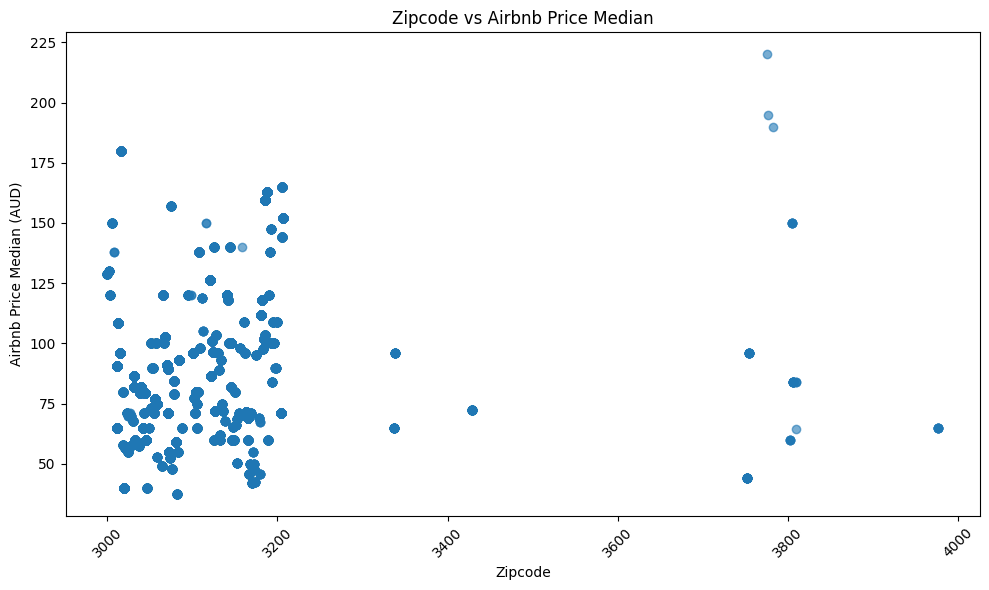

In [ ]:
# Hacer join con dataset Melbourne
melb_enriched = melb_df.merge(
    airbnb_final,
    left_on='Postcode',
    right_on='zipcode',
    how='left'
)

print(f"Dataset Melbourne original: {melb_df.shape}")
print(f"Dataset Melbourne enriquecido: {melb_enriched.shape}")
print(f"Propiedades con datos Airbnb: {melb_enriched['airbnb_price_clean_median'].notna().sum()}")

# Gráfico zipcode vs airbnb_price_median
plt.figure(figsize=(10, 6))

# Filtrar datos válidos para el gráfico
plot_data = melb_enriched[melb_enriched['airbnb_price_clean_median'].notna()]

plt.scatter(plot_data['Postcode'], plot_data['airbnb_price_clean_median'], alpha=0.6)
plt.xlabel('Zipcode')
plt.ylabel('Airbnb Price Median (AUD)')
plt.title('Zipcode vs Airbnb Price Median')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Interpretación:
- La mayoría de los puntos están agrupados en el rango de códigos postales entre 3000 y 3200.
- Esto indica que la mayoría de los datos de propiedades con precios disponibles se encuentran en esa zona.
- Zonas con poca densidad de datos:
  - Entre los códigos 3400 y 3700 hay pocos datos o datos faltantes.
  - Esto podría indicar zonas menos turísticas, rurales o sin propiedades listadas en Airbnb.

- Outliers / valores atípicos:
  - Algunos puntos tienen precios significativamente más altos (por encima de 200 AUD).
  - Estos pueden corresponder a propiedades de lujo o áreas muy exclusivas.



---
## 4. Investigación de Variables Alternativas para Combinación
### Variable 1: Suburb/Neighbourhood


In [ ]:
# Análisis de coincidencias por nombre de barrio
print("Análisis de variables de ubicación alternativas:")
print("\n1. SUBURB/NEIGHBOURHOOD:")

# Verificar si existe columna de barrio en Airbnb
neighbourhood_cols = [col for col in airbnb_df.columns
                     if any(keyword in col.lower() for keyword in ['neighbourhood', 'suburb'])]
print(f"Columnas relacionadas con barrios en Airbnb: {neighbourhood_cols}")

if 'neighbourhood_cleansed' in airbnb_df.columns:
    # Analizar coincidencias aproximadas
    melb_suburbs = set(melb_df['Suburb'].str.upper().unique())
    airbnb_neighbourhoods = set(airbnb_df['neighbourhood_cleansed'].str.upper().unique())

    # Coincidencias exactas
    exact_matches = melb_suburbs.intersection(airbnb_neighbourhoods)
    print(f"Coincidencias exactas de barrios: {len(exact_matches)}")
    print(f"Ejemplos: {list(exact_matches)[:10]}")

    # Coincidencias parciales (containment)
    partial_matches = []
    for melb_suburb in melb_suburbs:
        for airbnb_neighbourhood in airbnb_neighbourhoods:
            if melb_suburb in airbnb_neighbourhood or airbnb_neighbourhood in melb_suburb:
                partial_matches.append((melb_suburb, airbnb_neighbourhood))

    print(f"Coincidencias parciales encontradas: {len(partial_matches)}")

Análisis de variables de ubicación alternativas:

1. SUBURB/NEIGHBOURHOOD:
Columnas relacionadas con barrios en Airbnb: ['suburb']


**Justificación Suburb/Neighbourhood:**
- ✅ **Adecuada**: Los nombres de barrios suelen ser consistentes entre datasets
- ✅ **Ventajas**: Más granular que zipcode, mejor localización
- ⚠️ **Desafíos**: Variaciones en nomenclatura, abreviaciones, caracteres especiales
- 💡 **Solución**: Usar fuzzy matching o diccionarios de equivalencias con anotadores expertos

### Variable 2: Coordenadas Geográficas (Lat/Lng)

In [ ]:
# Verificar disponibilidad de coordenadas
geo_cols_airbnb = [col for col in airbnb_df.columns
                  if any(keyword in col.lower() for keyword in ['lat', 'lng', 'long', 'coord'])]
print(f"Columnas geográficas en Airbnb: {geo_cols_airbnb}")

# Simular análisis de densidad geográfica
if 'latitude' in airbnb_df.columns and 'longitude' in airbnb_df.columns:
    print("Análisis de distribución geográfica:")
    print(f"Rango Latitud: {airbnb_df['latitude'].min():.4f} - {airbnb_df['latitude'].max():.4f}")
    print(f"Rango Longitud: {airbnb_df['longitude'].min():.4f} - {airbnb_df['longitude'].max():.4f}")

    # Calcular densidad por área
    from scipy.spatial.distance import cdist

    # Ejemplo de cómo se calcularían distancias (conceptual)
    print("Métodos posibles con coordenadas:")
    print("- Buffer radial (ej: 500m, 1km, 2km)")
    print("- K-nearest neighbors (ej: 5, 10, 20 propiedades más cercanas)")


2. COORDENADAS GEOGRÁFICAS:
Columnas geográficas en Airbnb: ['latitude', 'longitude', 'cancellation_policy', 'calculated_host_listings_count']
Análisis de distribución geográfica:
Rango Latitud: -38.2244 - -37.4826
Rango Longitud: 144.4843 - 145.8391
Métodos posibles con coordenadas:
- Buffer radial (ej: 500m, 1km, 2km)
- K-nearest neighbors (ej: 5, 10, 20 propiedades más cercanas)
- Grid-based aggregation (ej: celdas de 0.01° x 0.01°)


**Justificación Coordenadas Geográficas:**
- ✅ **Muy Adecuada**: Máxima precisión espacial
- ✅ **Ventajas**: Permite análisis de proximidad exactos, control de radio
- ✅ **Flexibilidad**: Diferentes métodos (buffer, KNN, grid)
- ⚠️ **Requisitos**: Necesita algoritmos geoespaciales, mayor complejidad computacional

---
## 5. Uso de Coordenadas Geoespaciales
Ejemplo conceptual de uso de coordenadas geográficas

#### BUFFER RADIAL
- Para cada propiedad en Melbourne, crear un buffer de X metros
- Agregar todas las propiedades de Airbnb dentro del buffer
- **Ventaja**: Refleja mercado hiperlocal
- **Radio sugerido**: 500m–1km para áreas urbanas

```python
def aggregate_by_radius(melb_coords, airbnb_coords, airbnb_data, radius_km=1.0):
    """
    Pseudocódigo para agregación por radio
    """
    from geopy.distance import geodesic
    import pandas as pd

    results = []
    for melb_lat, melb_lng in melb_coords:
        nearby_airbnbs = []
        for idx, (airbnb_lat, airbnb_lng) in enumerate(airbnb_coords):
            distance = geodesic((melb_lat, melb_lng), (airbnb_lat, airbnb_lng)).kilometers
            if distance <= radius_km:
                nearby_airbnbs.append(airbnb_data.iloc[idx])

        if nearby_airbnbs:
            nearby_df = pd.DataFrame(nearby_airbnbs)
            agg_result = {
                'nearby_count': len(nearby_airbnbs),
                'price_median': nearby_df['price'].median(),
                'rating_mean': nearby_df['rating'].mean(),
                'distance_avg': nearby_df['distance'].mean()
            }
            results.append(agg_result)

    return results
```


---
### VARIABLES DESEABLES PARA MEJOR PREDICCIÓN DE PRECIOS

#### Infraestructura y Servicios
- Distancia a transporte público (tren, bus)
- Calidad de escuelas cercanas (ranking)
- Hospitales y centros de salud en radio de 2km
- Centros comerciales y retail nearby
- Espacios verdes y parques (área total en 1km)

#### Características Específicas de la Propiedad
- Estado de conservación (1-10)
- Orientación de la propiedad (norte, sur, etc.)
- Vista (mar, montaña, ciudad, sin vista)
- Amenities del edificio (gym, pool, concierge)
- Eficiencia energética (rating)



---
# Resumen de Implementación
**Conclusiones:**
1. Se agregaron 8 variables derivadas de Airbnb usando código postal como clave de unión
2. Se utilizó mediana en lugar de media para precios debido a distribuciones asimétricas
3. Las coordenadas geográficas serían la mejor alternativa para unión más precisa
4. Variables de infraestructura, calidad del barrio y características específicas mejorarían significativamente las predicciones


---
---
## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

## Ejercicios opcionales:

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)

In [ ]:
# TBD